# # Feature Engineering 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : Feature Engineering 기법을 이용한 타이타닉 생존 예측 모델 생성 *타이타닉: 당시 세계 최대 여객선으로 1912년 빙산과 충돌하여 침몰한 역사적인 선박
- 분석 단위 : 승객
- 종속 변수 : 생존 여부 (Survived)
- 설명 변수 : 승객정보 (성별, 나이, 운임, 부모/자녀 수, 객실번호 등)

[주요 실습 내용]
- EDA (탐색적 데이타 분석)
- Feature Transformation
- Feature Creation (파생변수 생성)
- Feature Selection


# 한글 폰트 설치


In [44]:
import sys, os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab(Linux)에서는 나눔고딕 설치 후 등록, macOS/Windows에서는 시스템 폰트 사용
if sys.platform.startswith("linux"):
    !apt-get -qq install -y fonts-nanum > /dev/null
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
    font_family = "NanumGothic"
else:
    installed = {f.name for f in fm.fontManager.ttflist}
    for cand in ["NanumGothic", "Nanum Gothic", "AppleGothic", "Malgun Gothic"]:
        if cand in installed:
            font_family = cand
            break
    else:
        font_family = plt.rcParams["font.family"][0]

plt.rc("font", family=font_family)
plt.rcParams["axes.unicode_minus"] = False
print("사용 폰트:", font_family)

사용 폰트: NanumGothic


# 데이타 준비
- 타이타닉(Titanic) 데이타 : titanic.csv
- 데이타 설명 : 타이타닉 배 침몰사고 당시의 실제 데이타를 기반으로 승객의 정보를 이용하여 생존 여부(Survived)를 예측하기 위함
- 변수 설명
| 변수          | 설명                 | 데이터 유형      |
| ----------- | ------------------ | ----------- |
| PassengerId | 승객 고유번호            | ID          |
| Survived    | 생존 여부 (0=사망, 1=생존) | Target      |
| Pclass      | 객실 등급 (1,2,3등석)    | 연속형    |
| Name        | 승객 이름              | 문자열         |
| Sex         | 성별                 | 범주형         |
| Age         | 나이                 | 연속형         |
| SibSp       | 함께 탑승한 형제·배우자 수    | 연속형     |
| Parch       | 함께 탑승한 부모·자녀 수     | 연속형     |
| Ticket      | 티켓 번호              | 문자열         |
| Fare        | 운임                 | 연속형         |
| Cabin       | 객실 번호              | 범주형 |
| Embarked    | 승선 항구(C, Q, S)     | 범주형         |



데이타 불러오기

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

데이터 조회하기

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


불필요 변수 제거

In [5]:
df = df.drop(columns=["PassengerId", "Ticket"])

컬럼정보 확인

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    str    
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형

# Feature Creation (파생변수 생성)

산술 조합 변수

In [7]:
import seaborn as sns

# '가족 크기' 변수 생성
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1    # SibSp(형제/배우자)와 Parch(부모/자녀)를 합침, +1은 본인

# FamilySize별 분포
print("\n[FamilySize별 분포]")
print(df['FamilySize'].value_counts())

# FamilySize별 생존율
print("\n[FamilySize별 생존율]")
print(df.groupby('FamilySize')['Survived'].mean())


[FamilySize별 분포]
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

[FamilySize별 생존율]
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


Text 특징 추출 : 키워드 기반
- 호칭 추출

In [8]:
# Name 컬럼으로 부터 'Mr.', 'Mrs.', 'Miss.' 같은 호칭을 추출

# 정규표현식으로 호칭 추출
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)   # ' ([A-Za-z]+)\.': 공백 뒤에 오는 알파벳 문자열을 찾고, 뒤에 마침표가 있으면 알파벳 문자열만 추출하라.

print("\n[추출된 Title 분포]")
print(df['Title'].value_counts())     # Master: 어린 소년, Mlle: 프랑스어 미혼 여성, Mme: Madame(기혼 여성)


[추출된 Title 분포]
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


- 호칭 Class 그룹핑

In [9]:
# 희귀 호칭 그룹화
title_counts = df['Title'].value_counts()
print(f"\n호칭 총 개수: {len(title_counts)}")

# 빈도 10 미만은 'Rare'로 묶기
rare_titles = title_counts[title_counts < 10].index.tolist()
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# 유사 호칭 통합 (Mlle, Ms → Miss / Mme → Mrs)
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

print("\n[그룹화 후 Title 분포]")
print(df['Title'].value_counts())

# Title별 생존율
print("\n[Title별 생존율]")
print(df.groupby('Title')['Survived'].agg(['mean', 'count']))


호칭 총 개수: 17

[그룹화 후 Title 분포]
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

[Title별 생존율]
            mean  count
Title                  
Master  0.575000     40
Miss    0.697802    182
Mr      0.156673    517
Mrs     0.792000    125
Rare    0.444444     27


Name 변수 제거

In [10]:
df = df.drop(columns=["Name"])

### [Self-Practice]

Q) 최소 1개 이상의 파생변수를 추가 생성하고, 종속변수(Survived)와의 관계를 분석하세요.

# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [11]:
import numpy as np

# 연속형 변수 기본 분포 확인
df.select_dtypes(include=[np.number]).describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


범주형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인
 - Missing 건수 확인
 - 데이터 밀집도 확인
 - 범주 갯수 확인

In [12]:
# 범주형 변수 자동 추출
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 범주 건수 & 비율 계산
for col in cat_cols:
    print(f"\n[{col}]")
    dist = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({
        "count": dist,
        "ratio_%": ratio.round(2)
    })
    print(result)


[Sex]
        count  ratio_%
Sex                   
male      577    64.76
female    314    35.24

[Cabin]
             count  ratio_%
Cabin                      
NaN            687    77.10
G6               4     0.45
C23 C25 C27      4     0.45
B96 B98          4     0.45
F33              3     0.34
...            ...      ...
E17              1     0.11
A24              1     0.11
C50              1     0.11
B42              1     0.11
C148             1     0.11

[148 rows x 2 columns]

[Embarked]
          count  ratio_%
Embarked                
S           644    72.28
C           168    18.86
Q            77     8.64
NaN           2     0.22

[Title]
        count  ratio_%
Title                 
Mr        517    58.02
Miss      182    20.43
Mrs       125    14.03
Master     40     4.49
Rare       27     3.03


/var/folders/yw/p75j2b1d3_s7p6l2_4fhmr1c0000gn/T/ipykernel_52990/2971682825.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


# Data Partition

- 목적 : 모델이 학습에 사용하지 않은 새로운 데이터에서도 잘 동작하는지 검증하기 위함
 - Train  : Test 비율 (7 : 3)
- Train Set : 모델 학습용, Test Set : 모델 평가용
- 데이타 변환시 변환 통계량은 Train 데이터에서 계산하고, Test 데이터에는 그 기준을 적용해야 함 (Data Leakage 문제)

In [13]:
from sklearn.model_selection import train_test_split

# Data Partition
df_train, df_test = train_test_split(
    df,
    test_size=0.3,     # test 30%
    random_state=42,   # 재현성
    shuffle=True       # 섞어서 분리
)

# Feature Transformation

원본 데이타 복제

In [14]:
df_train_raw = df_train.copy()
df_test_raw  = df_test.copy()

Missing 처리
- Missing 데이터 확인

In [15]:
# 변수별 결측치 개수
print("\n변수별 결측치 개수:")
print(df_train.isnull().sum())

# 결측치 비율 (%)
print("\n결측치 비율 (%):")
print((df_train.isnull().mean() * 100).round(2))


변수별 결측치 개수:
Survived        0
Pclass          0
Sex             0
Age           124
SibSp           0
Parch           0
Fare            0
Cabin         484
Embarked        1
FamilySize      0
Title           0
dtype: int64

결측치 비율 (%):
Survived       0.00
Pclass         0.00
Sex            0.00
Age           19.90
SibSp          0.00
Parch          0.00
Fare           0.00
Cabin         77.69
Embarked       0.16
FamilySize     0.00
Title          0.00
dtype: float64


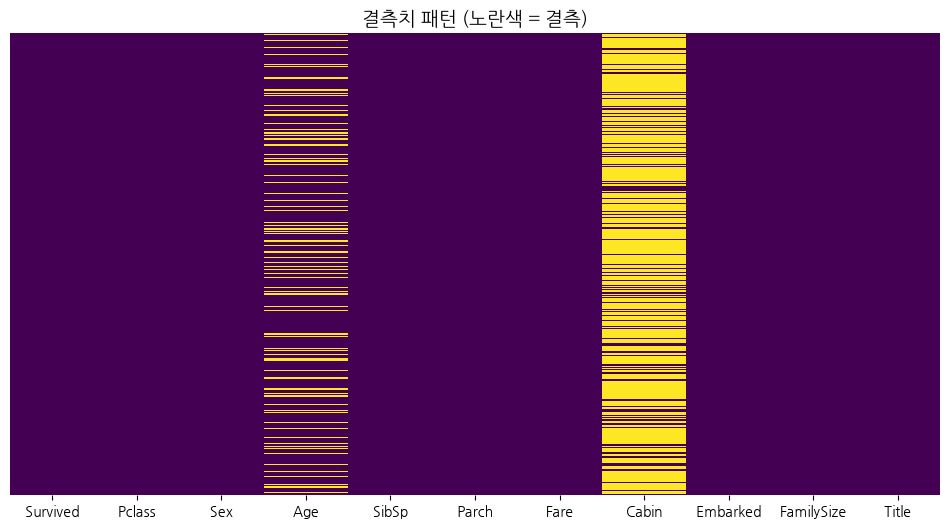

In [16]:
# 결측 패턴 시각화
plt.figure(figsize=(12, 6))
sns.heatmap(df_train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('결측치 패턴 (노란색 = 결측)', fontsize=14)
plt.show()

- 연속형 변수 처리

In [17]:
# 예시 : Age

# 방법 1: 단순 평균 대체
df_mean = df_train.copy()
df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean())

# 방법 2: 중앙값 대체
df_median = df_train.copy()
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())

# 방법 3: 그룹별 중앙값 대체
df_group = df_train.copy()
df_group['Age'] = df_group.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

Text(0.5, 0, 'Age')

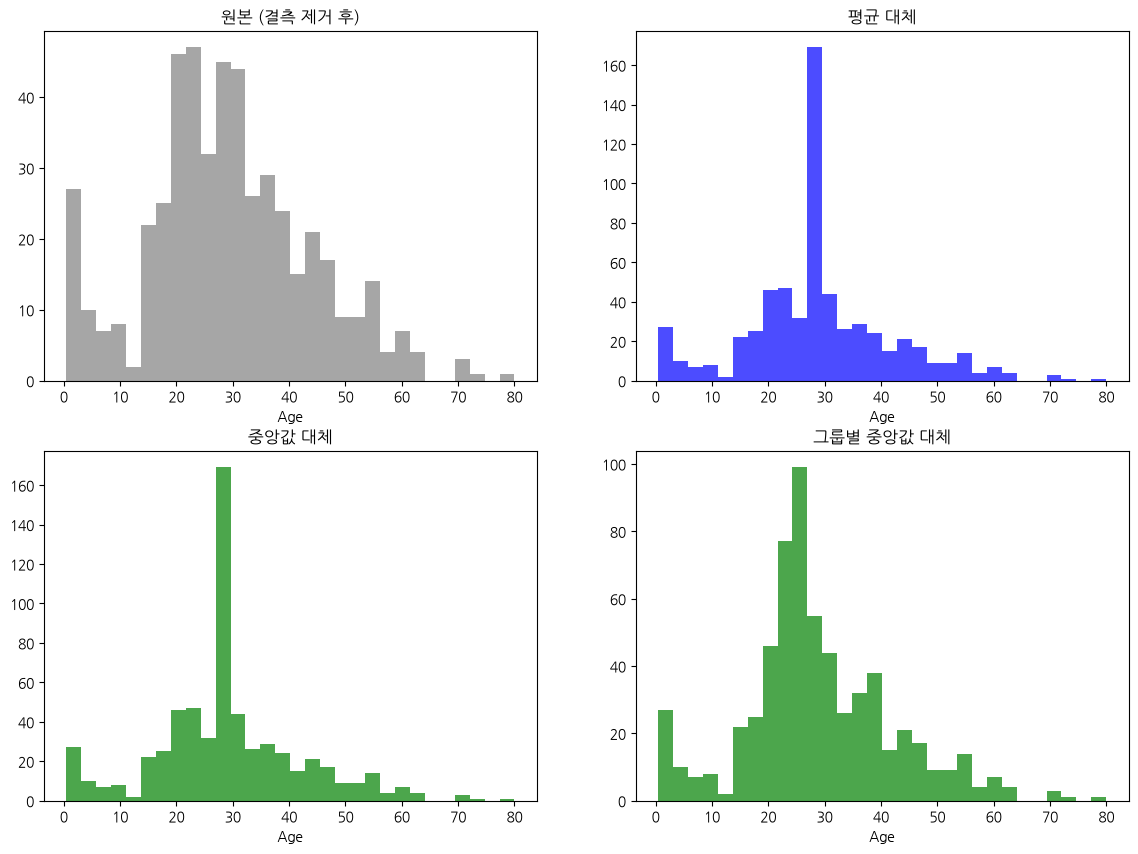

In [18]:
# 대체 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_train['Age'].dropna(), bins=30, color='gray', alpha=0.7)
axes[0, 0].set_title('원본 (결측 제거 후)')
axes[0, 0].set_xlabel('Age')

axes[0, 1].hist(df_mean['Age'], bins=30, color='blue', alpha=0.7)
axes[0, 1].set_title('평균 대체')
axes[0, 1].set_xlabel('Age')

axes[1, 0].hist(df_median['Age'], bins=30, color='green', alpha=0.7)
axes[1, 0].set_title('중앙값 대체')
axes[1, 0].set_xlabel('Age')

axes[1, 1].hist(df_group['Age'], bins=30, color='green', alpha=0.7)
axes[1, 1].set_title('그룹별 중앙값 대체')
axes[1, 1].set_xlabel('Age')

- 범주형 변수 처리

In [19]:
# 예시 : Embarked

# 방법 1) 최빈값 사용
df_mode = df_train.copy()
mode_embark = df_mode['Embarked'].mode()[0]
print(f"\nEmbarked 최빈값: {mode_embark}")
df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embark)

# 대체 후 결과
print("\n[최빈값 대체 결과]")
print(df_mode['Embarked'].value_counts())
print(f"\n범주별 생존율:")
print(df_mode.groupby('Embarked')['Survived'].mean())


Embarked 최빈값: S

[최빈값 대체 결과]
Embarked
S    458
C    110
Q     55
Name: count, dtype: int64

범주별 생존율:
Embarked
C    0.563636
Q    0.381818
S    0.323144
Name: Survived, dtype: float64


In [20]:
# 방법 2) "Unknown" 대체
df_unknown = df_train.copy()
col = 'Embarked'
if df_unknown[col].dtype.name == 'category':
  df_unknown[col] = df_unknown[col].cat.add_categories('Unknown')
df_unknown[col] = df_unknown[col].fillna('Unknown')

# 대체 후 결과
print("\n[Unknown 대체 결과]")
print(df_unknown['Embarked'].value_counts())
print(f"\n범주별 생존율:")
print(df_unknown.groupby('Embarked')['Survived'].mean())


[Unknown 대체 결과]
Embarked
S          457
C          110
Q           55
Unknown      1
Name: count, dtype: int64

범주별 생존율:
Embarked
C          0.563636
Q          0.381818
S          0.321663
Unknown    1.000000
Name: Survived, dtype: float64


- Train / Test 일괄 Missing 처리
   - 연속형 변수 처리 : median 대체

In [21]:
# 연속형 변수 처리 : median 대체

# 연속형 변수만 선택
num_cols = df_train.select_dtypes(include=[np.number]).columns

# train 기준 중앙값 계산
median_values = df_train[num_cols].median()

# train, test 모두 중앙값으로 결측치 대체
df_train[num_cols] = df_train[num_cols].fillna(median_values)
df_test[num_cols]  = df_test[num_cols].fillna(median_values)

- Train / Test 일괄 Missing 처리
   - 범주형 변수 처리 : Unknown 대체

In [22]:
# 범주형 변수만 선택
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns

# 신규 범주 (Unknown) 로 대체
for col in cat_cols:
    # train
    if df_train[col].dtype.name == 'category':
        df_train[col] = df_train[col].cat.add_categories('Unknown')
    df_train[col] = df_train[col].fillna('Unknown')

    # test
    if df_test[col].dtype.name == 'category':
        df_test[col] = df_test[col].cat.add_categories('Unknown')
    df_test[col] = df_test[col].fillna('Unknown')

/var/folders/yw/p75j2b1d3_s7p6l2_4fhmr1c0000gn/T/ipykernel_52990/3462125122.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include=['object', 'category']).columns


Missing 데이터 재확인

In [23]:
# 변수별 결측치 개수
df_train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin         0
Embarked      0
FamilySize    0
Title         0
dtype: int64

Outlier 처리
- 방법1) IQR 방식



Fare 이상치: 82개
정상 범위: -26.31 ~ 64.99


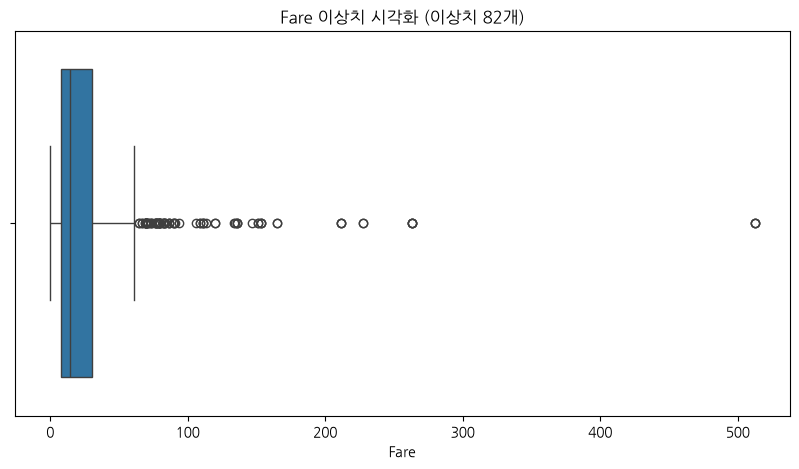

In [24]:
# 예시 : Fare

# ==========================================
# 이상치 탐지
# ==========================================

def detect_outliers_iqr(data, column):
    """IQR 기반 이상치 탐지 함수"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# 이상치 탐지, 예) Fare
outliers_fare, low, high = detect_outliers_iqr(df_train, 'Fare')
print(f"\nFare 이상치: {len(outliers_fare)}개")
print(f"정상 범위: {low:.2f} ~ {high:.2f}")

# 시각화
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_train['Fare'])
plt.title(f'Fare 이상치 시각화 (이상치 {len(outliers_fare)}개)')
plt.show()

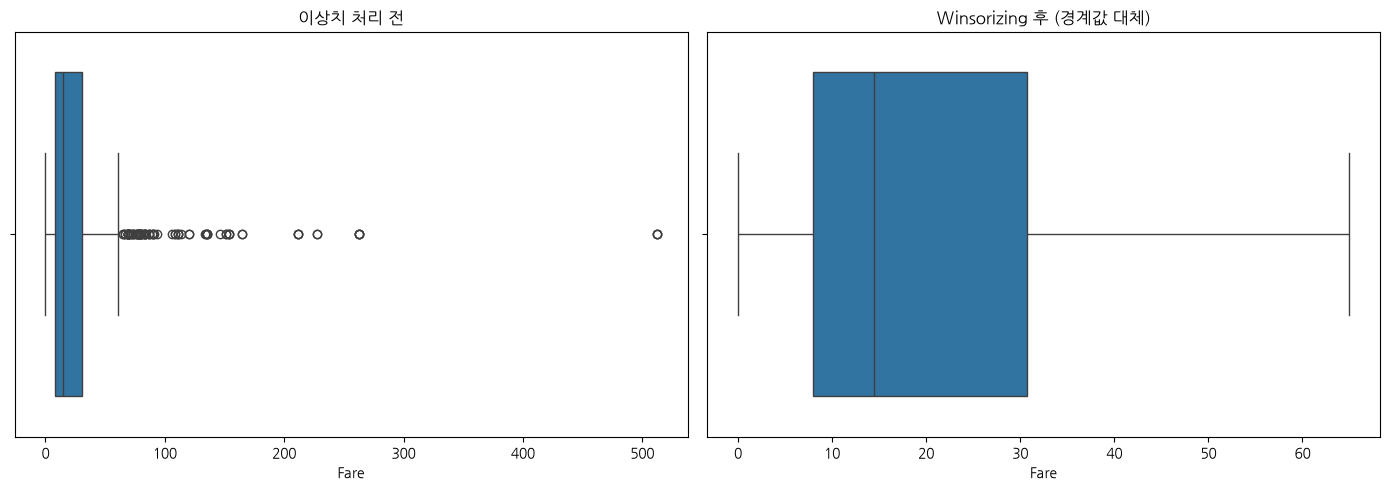

In [25]:
# ==========================================
# 이상치 대체 : 경계값 대체 (Winsorizing)
# ==========================================

df_winsor = df_train.copy()

# 이상치를 경계값으로 대체,  예) Fare
df_winsor['Fare'] = df_winsor['Fare'].clip(lower=low, upper=high)

# Before/After 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df_train['Fare'], ax=axes[0])
axes[0].set_title('이상치 처리 전')

sns.boxplot(x=df_winsor['Fare'], ax=axes[1])
axes[1].set_title('Winsorizing 후 (경계값 대체)')
plt.tight_layout()
plt.show()

- 방법2) 백분위수 방식 : 1%, 99%

In [26]:
# 예시 : Fare

# ==========================================
# 이상치 탐지
# ==========================================

def detect_outliers_iqr(data, column):
    """백분위수 기반 이상치 탐지 함수"""
    Q01 = data[column].quantile(0.01)
    Q99 = data[column].quantile(0.99)

    lower = Q01
    upper = Q99
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# 이상치 탐지, 예) Fare
outliers_fare, low, high = detect_outliers_iqr(df_train, 'Fare')
print(f"\nFare 이상치: {len(outliers_fare)}개")
print(f"정상 범위: {low:.2f} ~ {high:.2f}")


# ==========================================
# 이상치 대체 : 경계값 대체 (Winsorizing)
# ==========================================

df_winsor = df_train.copy()

# 이상치를 경계값으로 대체,  예) Fare
df_winsor['Fare'] = df_winsor['Fare'].clip(lower=low, upper=high)


Fare 이상치: 7개
정상 범위: 0.00 ~ 255.20


### [Self-Practice]

Q) 위와 동일한 방식으로 Z-Score 방식 (|Z| > 3) 을 적용하여 Fare 변수 이상치 탐지를 하고, 이상치 개수와 정상 범위를 확인하세요.

- Train / Test 일괄 이상치 처리
  - 이상치 탐지 : IQR 방식
  - 이상치 대체 : 경계값 대체 (Winsorizing)

In [27]:
# 연속형 변수 선택
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

# 종속변수 제외
num_cols.remove("Survived")

# 모든 연속형 변수에 이상치 처리 적용
for col in num_cols:

    # Train 기준 lower, upper 경계값 추출
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Train 기준 경계값으로 Train/Test 모두 처리
    df_train[col] = df_train[col].clip(lower=lower, upper=upper)
    df_test[col] = df_test[col].clip(lower=lower, upper=upper)

분포 변환
- 로그 변환 예시


[변환 전 Fare]
  Skewness (왜도): 1.081
  평균: 23.85
  중앙값: 14.45

[로그 변환 후]
  Skewness: -0.263
  평균: 2.89
  중앙값: 2.74


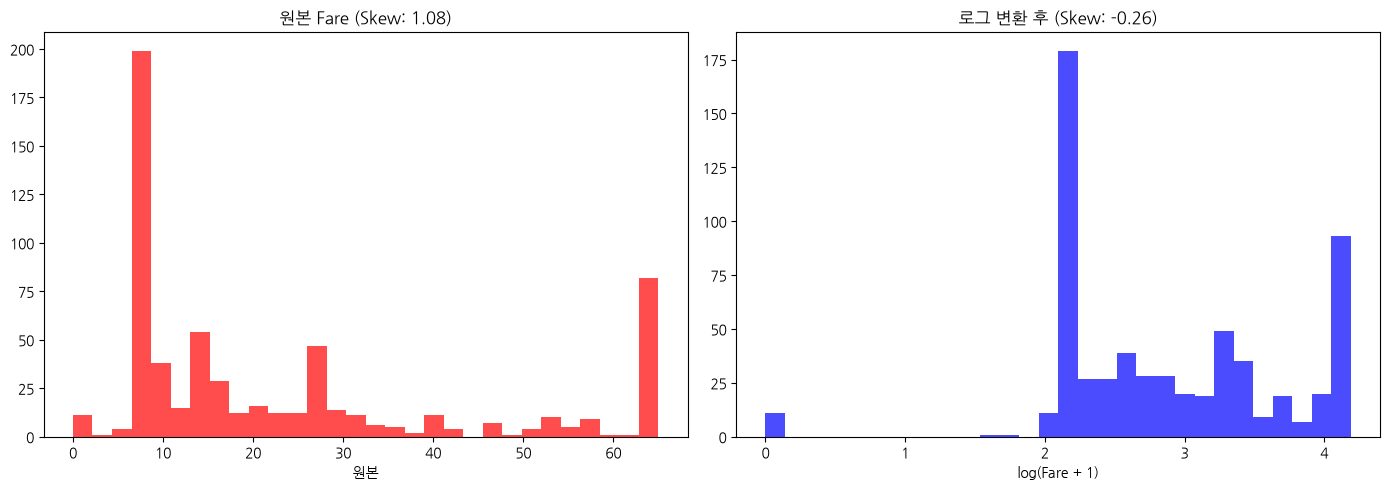

In [28]:
# 예시 : Fare

# 변환 전 분포
print(f"\n[변환 전 Fare]")
print(f"  Skewness (왜도): {df_train['Fare'].skew():.3f}")  # 왜도 (>0: 왼쪽으로 치우침, <0: 오른쪽으로 치우팀, 0=좌우 대칭)
print(f"  평균: {df_train['Fare'].mean():.2f}")
print(f"  중앙값: {df_train['Fare'].median():.2f}")

# 로그 변환
fare_log = np.sign(df_train['Fare']) * np.log1p(df_train['Fare'])

print(f"\n[로그 변환 후]")
print(f"  Skewness: {fare_log.skew():.3f}")
print(f"  평균: {fare_log.mean():.2f}")
print(f"  중앙값: {fare_log.median():.2f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['Fare'], bins=30, color='red', alpha=0.7)
axes[0].set_title(f'원본 Fare (Skew: {df_train["Fare"].skew():.2f})')
axes[0].set_xlabel('원본')

axes[1].hist(fare_log, bins=30, color='blue', alpha=0.7)
axes[1].set_title(f'로그 변환 후 (Skew: {fare_log.skew():.2f})')
axes[1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.show()

- Train / Test 일괄 로그 변환

In [29]:
import pandas as pd
import numpy as np

# ==========================================
# 변수 분리
# ==========================================

# 전체 연속형 변수 추출 후 'Survived' 제외
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

# Survived 제외
num_cols.remove("Survived")

# 범주형 변수 추출
cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist()


# ==========================================
# Log Transformation 함수 정의
# ==========================================

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


# ==========================================
# Train 및 Test 데이터 변환 적용
# ==========================================

# Train 연속형 변수 변환
train_log = df_train[num_cols].apply(signed_log1p)

# Test 연속형 변수 변환
test_log = df_test[num_cols].apply(signed_log1p)


# ==========================================
# 데이터 병합 (변환된 변수 + 원본 Survived + 범주형)
# ==========================================

# df_train
df_train = pd.concat(
    [
        train_log,                 # Log 변환된 연속형 피처들
        df_train[["Survived"]],    # 원본 타겟 변수
        df_train[cat_cols]         # 범주형 변수들
    ],
    axis=1
)

# df_test
df_test = pd.concat(
    [
        test_log,                  # Log 변환된 연속형 피처들
        df_test[["Survived"]],     # 원본 타겟 변수
        df_test[cat_cols]          # 범주형 변수들
    ],
    axis=1
)

/var/folders/yw/p75j2b1d3_s7p6l2_4fhmr1c0000gn/T/ipykernel_52990/757900742.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist()


데이타 Scaling
- Z-Score 변환 : Train / Test 일괄 처리

In [30]:
from sklearn.preprocessing import StandardScaler

# =========================
# 변수 분리
# =========================

# 연속형 변수
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

# Survived 제외
num_cols.remove("Survived")

# 범주형 변수
cat_cols = df_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# =========================
# StandardScaler Scaling
# =========================

scaler = StandardScaler()

# Train 기준 학습
train_scaled = pd.DataFrame(
    scaler.fit_transform(df_train[num_cols]),
    columns=num_cols,
    index=df_train.index
)

# Test는 동일 기준 적용
test_scaled = pd.DataFrame(
    scaler.transform(df_test[num_cols]),
    columns=num_cols,
    index=df_test.index
)

# 결과 확인
print("\n[StandardScaler 결과 - Train]")
print(f"평균:       {train_scaled.mean().round(3).values}")
print(f"표준편차:   {train_scaled.std().round(3).values}")
print(f"최소값:     {train_scaled.min().round(3).values}")
print(f"최대값:     {train_scaled.max().round(3).values}")


# =========================
# 데이터 병합 : 변환 값 + 범주형 + Target 변수 병합
# =========================

df_train = pd.concat(
    [
        train_scaled,                # 표준화된 연속형 변수
        df_train[["Survived"]],      # 원본 Survived
        df_train[cat_cols]           # 범주형 변수
    ],
    axis=1
)

df_test = pd.concat(
    [
        test_scaled,
        df_test[["Survived"]],
        df_test[cat_cols]
    ],
    axis=1
)


[StandardScaler 결과 - Train]
평균:       [ 0. -0.  0.  0. -0. -0.]
표준편차:   [1.001 1.001 1.001 0.    1.001 1.001]
최소값:     [-1.707 -3.417 -0.664  0.    -3.458 -0.767]
최대값:     [0.771 1.272 2.36  0.    1.56  1.811]


/var/folders/yw/p75j2b1d3_s7p6l2_4fhmr1c0000gn/T/ipykernel_52990/124124440.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(


### [Self-Practice]

Q) Min-Max 변환으로 Train / Test 일괄 처리하고, Train 데이타 기준으로 평균/ 표준편차/ 최소값/ 최대값 확인하기

범주형 변수 인코딩
- 범주형 변수 범주 개수 확인

In [31]:
# 범주형 변수 자동 식별
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n[문자형 컬럼]:", categorical_cols)

# 각 변수의 고유값 개수
print("\n[변수별 범주 개수]")
for col in categorical_cols:
    n_unique = df_train[col].nunique()
    print(f"  {col}: {n_unique}개")


[문자형 컬럼]: ['Sex', 'Cabin', 'Embarked', 'Title']

[변수별 범주 개수]
  Sex: 2개
  Cabin: 107개
  Embarked: 4개
  Title: 5개


/var/folders/yw/p75j2b1d3_s7p6l2_4fhmr1c0000gn/T/ipykernel_52990/1575679616.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()


- 범주 개수가 많지 않은 경우
   - One-Hot Encoding (가장 일반적)

In [32]:
# 예시 : 'Sex', 'Embarked'

# k-1 Dummy 변수 생성, *다중공선성 방지 (한 컬럼은 나머지로 추론 가능)
df_onehot = pd.get_dummies(df_train, columns=['Sex', 'Embarked'], drop_first=True)   # True: k-1개 dummy, False: One-Hot Encoding

print("\n[One-Hot Encoding 결과]")
print(f"원본 컬럼 수: {df_train.shape[1]}")
print(f"적용 후 컬럼 수: {df_onehot.shape[1]}")
print(f"\n생성된 컬럼: {[c for c in df_onehot.columns if 'Sex_' in c or 'Embarked_' in c]}")

# 미리보기
print("\n[변환 결과 미리보기]")
print(df_onehot[['Sex_male', 'Embarked_Q', 'Embarked_S', 'Embarked_Unknown']].head())


[One-Hot Encoding 결과]
원본 컬럼 수: 11
적용 후 컬럼 수: 13

생성된 컬럼: ['Sex_male', 'Embarked_Q', 'Embarked_S', 'Embarked_Unknown']

[변환 결과 미리보기]
     Sex_male  Embarked_Q  Embarked_S  Embarked_Unknown
445      True       False        True             False
650      True       False        True             False
172     False       False        True             False
450      True       False        True             False
314      True       False        True             False


- 범주 순서가 의미 있을때 or Tree 계열 모델 적용 시
   - Label Encoding

In [33]:
# 예시 : 'Embarked'

from sklearn.preprocessing import LabelEncoder

# Label Encoding
le = LabelEncoder()
df_le = df_train.copy()
df_le['Embarked_Label'] = le.fit_transform(df_le['Embarked'])

print("\n[변환 결과 미리보기]")
print(df_le[['Embarked', 'Embarked_Label']].head(10))
print(f"\n매핑: {dict(zip(le.classes_, le.transform(le.classes_)))}")


[변환 결과 미리보기]
    Embarked  Embarked_Label
445        S               2
650        S               2
172        S               2
450        S               2
314        S               2
332        S               2
801        S               2
90         S               2
834        S               2
181        C               0

매핑: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2), 'Unknown': np.int64(3)}


- 범주 개수가 너무 많은 경우
   - 빈도 기반 그룹핑

In [34]:
# Cabin은 결측치 현황
print(f"\n[Cabin 고유값 개수]: {df_train['Cabin'].nunique()}")

# 첫 글자만 추출 → 'CabinLetter'로 차원 축소
df_cabin = df_train.copy()
df_cabin['CabinLetter'] = df_cabin['Cabin'].str[0]

print(f"\n[Cabin → CabinLetter 변환]")

# 빈도 기반 그룹화 - 빈도 20 미만은 'Other'로
cabin_counts = df_cabin['CabinLetter'].value_counts()
print(f"\n[빈도 분포]")
print(cabin_counts)

rare_letters = cabin_counts[cabin_counts < 20].index
df_cabin['CabinGrouped'] = df_cabin['CabinLetter'].apply(
    lambda x: 'Other' if x in rare_letters else x
)
print(f"\n[그룹화 후]")
print(df_cabin['CabinGrouped'].value_counts())


[Cabin 고유값 개수]: 107

[Cabin → CabinLetter 변환]

[빈도 분포]
CabinLetter
U    484
C     41
B     32
E     23
D     18
F     11
A     10
G      3
T      1
Name: count, dtype: int64

[그룹화 후]
CabinGrouped
U        484
Other     43
C         41
B         32
E         23
Name: count, dtype: int64


- Train / Test 일괄 인코딩
   - 빈도 기반 그룹핑 : 'Cabin'

In [35]:
# 첫 글자 추출 (train, test 동시 적용)
for df in [df_train, df_test]:
    df['Cabin_new'] = df['Cabin'].str[0]

# train 기준으로 rare 그룹 정의
rare_letters = df_train['Cabin_new'].value_counts()[lambda x: x < 20].index

# rare 그룹 -> 'Other', 원본 Cabin 삭제
for df in [df_train, df_test]:
    df['Cabin_new'] = df['Cabin_new'].apply(lambda x: 'Other' if x in rare_letters else x)
    df.drop(columns='Cabin', inplace=True)

- Train / Test 일괄 인코딩
   - One-Hot Encoding

In [36]:
# 범주형 컬럼 선택
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

# k-1 dummy 변수화
# Train Set
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)   # True: k-1개 dummy, False: One-Hot Encoding

# Test Set
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# test를 train 컬럼 구조에 맞추기 (train에는 있고 test에 없는 컬럼은 0으로, train에 없는 test컬럼은 제거)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

/var/folders/yw/p75j2b1d3_s7p6l2_4fhmr1c0000gn/T/ipykernel_52990/4110505171.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()


# X, y 분리

In [37]:
# train
Y_train = df_train['Survived']
X_train = df_train.drop(columns=['Survived'])

# test
Y_test = df_test['Survived']
X_test = df_test.drop(columns=['Survived'])

# Feature Selection
- 일반적으로 파생변수 생성 -> 데이타 분할 -> 데이타 변환 (Feature Transformation) -> Feature Selection 순으로 진행

Feature 신뢰성 검증
- 단일값 변수 제거

In [38]:
# 고유값 개수 계산 (NaN 포함)
unique_counts = X_train.nunique(dropna=False)

# 고유값이 1개 이하인 컬럼 식별
cols_to_drop = unique_counts[unique_counts <= 1].index.tolist()

# 데이터셋에서 삭제
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"삭제된 컬럼: {cols_to_drop}")

삭제된 컬럼: ['Parch']


- 상관 분석 : 변수간 중복성 검증 목적
  - 설명변수간 상관계수 산출

In [39]:
# 연속형 변수 컬럼 감지
continuous_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 상관행렬 계산
corr_matrix = X_train[continuous_cols].corr()

# 상삼각(Upper Triangle) 행렬의 인덱스 추출 (대각선 제외, 중복 제거)
upper_idx = np.triu_indices_from(corr_matrix, k=1)

# 변수1, 변수2, 상관계수 형태의 DataFrame 생성
corr_df = pd.DataFrame({
    '변수1': corr_matrix.columns[upper_idx[0]],
    '변수2': corr_matrix.columns[upper_idx[1]],
    '상관계수': corr_matrix.values[upper_idx]
})

# 상관계수 절대값 기준 내림차순 정렬
corr_df = corr_df.reindex(corr_df['상관계수'].abs().sort_values(ascending=False).index)

# 결과 출력
print("=== 연속형 변수 상관분석 (상관계수 높은 순) ===")
print(corr_df.to_string(index=False))

=== 연속형 변수 상관분석 (상관계수 높은 순) ===
   변수1        변수2      상관계수
 SibSp FamilySize  0.849283
Pclass       Fare -0.623553
  Fare FamilySize  0.482643
 SibSp       Fare  0.429653
   Age FamilySize -0.373840
   Age      SibSp -0.308630
Pclass        Age -0.245664
Pclass FamilySize -0.035237
   Age       Fare -0.020360
Pclass      SibSp -0.002843


- 상관계수 높은 변수 제거

In [40]:
# 연속형/범주형 컬럼 구분
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("최초 X변수 수:", X_train.shape[1])

# Train 기준 상관분석 → 제거할 변수 선정
corr = X_train[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# 상관계수 임계값
threshold = 1.0  # max: 1.0
to_drop = [col for col in upper.columns if (upper[col] >= threshold).any()]

print("제거된 연속형 변수 리스트:")
print(to_drop)

# Train/Valid/Test 동일하게 제거
X_train = X_train.drop(columns=to_drop, errors="ignore")
X_test = X_test.drop(columns=to_drop, errors="ignore")

print("제거 후 X변수 수:", X_train.shape[1])

최초 X변수 수: 17
제거된 연속형 변수 리스트:
[]
제거 후 X변수 수: 17


Feature 중요도 검증
- Feature Importance 분석 : Random Forest


[Random Forest 기준 Feature Importance]
         feature  importance
            Fare    0.213977
             Age    0.203816
        Title_Mr    0.126986
        Sex_male    0.118070
          Pclass    0.072641
      FamilySize    0.046949
           SibSp    0.040292
       Title_Mrs    0.039638
     Cabin_new_U    0.034573
      Embarked_S    0.028678
      Title_Miss    0.024425
     Cabin_new_E    0.012920
      Embarked_Q    0.011245
     Cabin_new_C    0.009729
 Cabin_new_Other    0.008631
      Title_Rare    0.007425
Embarked_Unknown    0.000007

[총 feature 갯수] 17


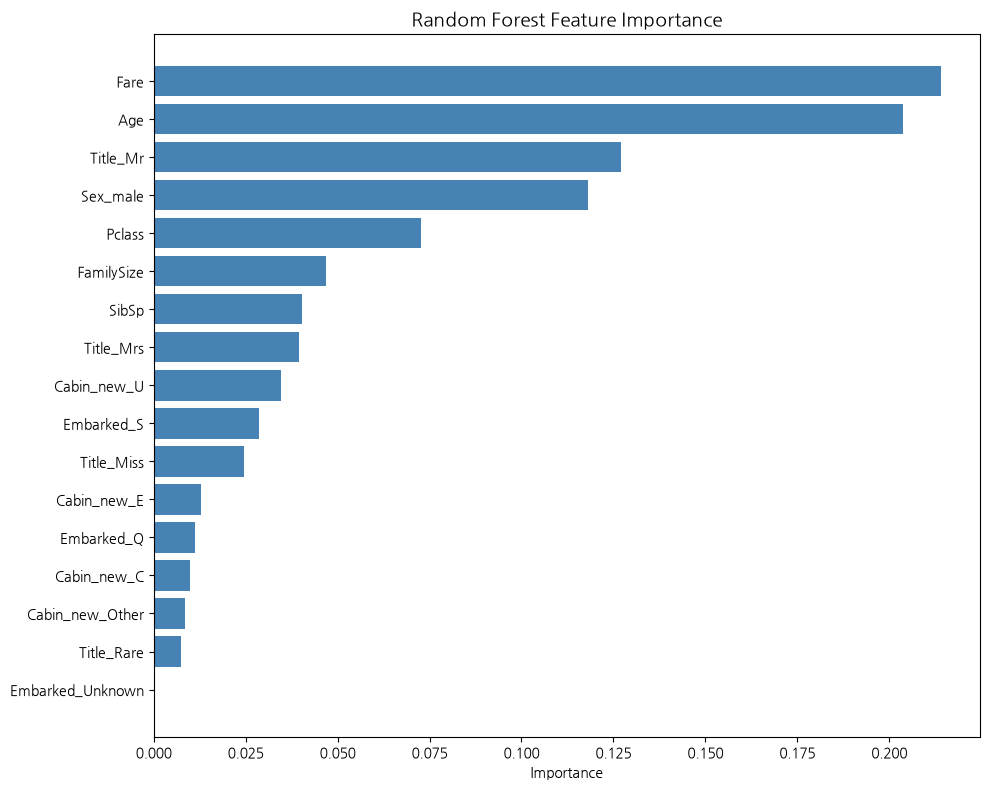

In [41]:
from sklearn.ensemble import RandomForestClassifier

# RandomForest 모델 학습
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, Y_train)

# Feature Importance 추출
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n[Random Forest 기준 Feature Importance]")
print(importance_df.to_string(index=False))

print("\n[총 feature 갯수]", len(X_train.columns))

# 시각화
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')
plt.title('Random Forest Feature Importance', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

- Feature Importance 기반 변수 선택

In [42]:
# 중요도 상위 Feature 선택

print("\n[총 feature 갯수]")
max_features = len(X_train.columns)
print(f"개수: {max_features}")

TOP_N = max_features    # 원하는 상위 Feature 개수로 변경, 선택 안할 경우: max_features
final_features = importance_df.loc[:TOP_N-1, "feature"].tolist()

print(f"\n[최종 선택 변수]")
print(f"개수: {len(final_features)}")
print(f"변수: {final_features}")

# 최종 X 데이타
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]


[총 feature 갯수]
개수: 17

[최종 선택 변수]
개수: 17
변수: ['Fare', 'Age', 'Title_Mr', 'Sex_male', 'Pclass', 'FamilySize', 'SibSp', 'Title_Mrs', 'Cabin_new_U', 'Embarked_S', 'Title_Miss', 'Cabin_new_E', 'Embarked_Q', 'Cabin_new_C', 'Cabin_new_Other', 'Title_Rare', 'Embarked_Unknown']


# 모델 학습 및 평가

In [43]:
from sklearn.metrics import accuracy_score

# 모델 학습 : RandomForestClassifier
rf_final = RandomForestClassifier(n_estimators=300, random_state=42)
rf_final.fit(X_train_final, Y_train)

# 모델 평가
acc_train = accuracy_score(Y_train, rf_final.predict(X_train_final))
acc_test  = accuracy_score(Y_test, rf_final.predict(X_test_final))

print(f"\n[최종 모델 성능]")
print(f"변수 수   : {len(X_train_final.columns)}")
print(f"Train 성능 : {acc_train:.4f}")
print(f"Test 성능  : {acc_test:.4f}")


[최종 모델 성능]
변수 수   : 17
Train 성능 : 0.9823
Test 성능  : 0.7873


### [Self-Practice]

Q1) 상관계수 임계값 (1.0, 0.80, 0.60. 0.30) 에 따른 모델 성능 변화를 확인하세요 (변수 수/ Train 성능/ Test 성능). 단, Feature Importance를 적용하지 않은 상태에서 상관계수 효과만 확인하세요.  
Q2) 상관계수를 적용하지 않은 상태에서 Feature Importance 선택 변수 수를 변경하면서 Train 성능/ Test 성능 변화를 확인하세요.
> 변수 수 : 1, 2, 3, 5, 7, 10, 15, 최대 변수 수(예:17)
